In [1]:
# -----------------------------
# Setup
# -----------------------------
import numpy as np
import pandas as pd
import re
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

In [2]:
# -----------------------------
# Load Datasets
# -----------------------------
variants_data = pd.read_csv("../data/losAlomosData4ML.csv")
variants_data_full = variants_data
#variants_data.head()
stanford_muts = pd.read_csv('../data/Stanford-resistance-comments.csv')
stanford_mut_list = set(stanford_muts['Mutation'])
variants_data.shape

variants_data = variants_data.loc[:, ~variants_data.columns.str.contains(r'[\*\-]')]
print(variants_data.shape)

target = 'Status'
test_size = 0.2
pos_label = 'yes'
perc_top_features = 0.01 #we analyse the top 1% mutations
gene = 'IN'
algor_colors = ["#6082B6","#2AAA8A","#E3963E"]
y = variants_data[[target]].values.ravel()

# get rid of mixture mutations

drop_vars = ['Status','Year', 'Subtype', 'Georegion']
#drop_vars = ['Status']#,'Sample']

pure_mutation_pattern = r'^[A-Z][0-9]+[A-Z]$'

mixed_variants_data = variants_data.loc[:, ~variants_data.columns.str.match(pure_mutation_pattern)]
variants_data = variants_data.loc[:, variants_data.columns.str.match(pure_mutation_pattern)]

(41247, 8118)


In [3]:
rf_muts = [
    "A205S", "A248S", "A265V", "A91T", "D232K", "D278A", "D288E", "D3L",
    "D41X", "D6E", "E11D", "E198Q", "E287L", "E35Q", "G106X", "G134N",
    "G149R", "G163E", "G193E", "G193R", "G47A", "G4R", "G70E", "G82K",
    "H171S", "I135V", "I141V", "I162X", "I200L", "I200R", "I203M", "I204V",
    "I217L", "I217P", "I220L", "I220N", "I251F", "I267L", "I60A", "I72V",
    "I84M", "K136Q", "K136T", "K215G", "K215Q", "K236P", "L101I", "L102L",
    "L172X", "L241R", "L74K", "M178S", "M275L", "M50L", "P233A", "P233L",
    "P90A", "Q177X", "Q216K", "Q216P", "Q221L", "Q252K", "Q274S", "R166K",
    "R166S", "R224Q", "R224X", "R269K", "R284M", "S119P", "S230L", "S24G",
    "S24H", "S255Q", "S283G", "S39N", "T112V", "T122I", "T124N", "T125A",
    "T206S", "T210S", "T218S", "V150X", "V165L", "V201I", "V225T", "V281M",
    "V31I", "Y83F"
]

# rf_muts = ['S283G', 'T112V', 'D278A', 'K136Q', 'T125A', 'V201I', 'V31I', 'T124A',
#           'I72V', 'L101I', 'K14R', 'E11D', 'A265V', 'G134N', 'T124N', 'D167E',
#           'D256E', 'T206S', 'S17N', 'I135V']

rf_muts.append('Status')
df5 = variants_data_full[rf_muts]
df5['Status'].value_counts()

# Function to perform Fisher's Exact test on each column against 'status'
def fisher_exact_tests_with_proportions(df, status_col='Status'):
    results = []

    for col in df.columns:
        if col == status_col:
            continue

        # Create a 2x2 contingency table
        contingency_table = pd.crosstab(df[col], df[status_col])
        #print(contingency_table)
        # Perform Fisher's Exact test
        _, p_value = fisher_exact(contingency_table)

        # Get the counts for each level in the status column
        count_00 = contingency_table.iloc[0, 0]  # Count for col=0, status=0
        count_01 = contingency_table.iloc[0, 1]  # Count for col=0, status=1
        count_10 = contingency_table.iloc[1, 0]  # Count for col=1, status=0
        count_11 = contingency_table.iloc[1, 1]  # Count for col=1, status=1
        
        # Calculate total counts for proportions
        total_status_0 = count_00 + count_10  # Total for status=0
        total_status_1 = count_01 + count_11  # Total for status=1

        # Calculate proportions
        prop_10 = count_10 / total_status_0 
        prop_11 = count_11 / total_status_1 
        
        # overall prevalence
        count_mut_present =  count_10 + count_11
        overall_prop = count_mut_present /(count_00 + count_01 + count_10 + count_11)

        # Append results with proportions
        results.append({
            'Column': col,
            'P-value': p_value,
            'Total Naive': total_status_0,
            'Total Treated': total_status_1,
            'Count Naive': count_10,
            'Count Treated': count_11,
            'Naive': prop_10,
            'Treated': prop_11,
            'Overall count': count_mut_present,
            'Overall prev': overall_prop
        })

    return pd.DataFrame(results)

# Example usage
# Replace with your actual DataFrame
# df = pd.read_csv('your_file.csv')
df_results = fisher_exact_tests_with_proportions(df5)

print(df_results)

   Column        P-value  Total Naive  Total Treated  Count Naive  \
0   A205S  5.258699e-234        19762          21485         1390   
1   A248S   0.000000e+00        19762          21485         1344   
2   A265V  3.974887e-223        19762          21485         1758   
3    A91T   4.257954e-39        19762          21485          124   
4   D232K   6.256368e-28        19762          21485           85   
..    ...            ...          ...            ...          ...   
85  V201I   0.000000e+00        19762          21485         9358   
86  V225T   0.000000e+00        19762          21485         1131   
87  V281M   1.243433e-20        19762          21485          633   
88   V31I  9.991097e-196        19762          21485         6032   
89   Y83F   4.029181e-66        19762          21485          410   

    Count Treated     Naive   Treated  Overall count  Overall prev  
0             227  0.070337  0.010566           1617      0.039203  
1              50  0.068009  0.00

In [4]:
df_results

,Column,P-value,Total Naive,Total Treated,Count Naive,Count Treated,Naive,Treated,Overall count,Overall prev
0,A205S,5.258699e-234,19762,21485,1390,227,0.070337,0.010566,1617,0.039203
1,A248S,0.000000e+00,19762,21485,1344,50,0.068009,0.002327,1394,0.033796
2,A265V,3.974887e-223,19762,21485,1758,4260,0.088959,0.198278,6018,0.145902
3,A91T,4.257954e-39,19762,21485,124,449,0.006275,0.020898,573,0.013892
4,D232K,6.256368e-28,19762,21485,85,0,0.004301,0.000000,85,0.002061
...,...,...,...,...,...,...,...,...,...,...
85,V201I,0.000000e+00,19762,21485,9358,15118,0.473535,0.703654,24476,0.593401
86,V225T,0.000000e+00,19762,21485,1131,2,0.057231,0.000093,1133,0.027469
87,V281M,1.243433e-20,19762,21485,633,383,0.032031,0.017826,1016,0.024632
88,V31I,9.991097e-196,19762,21485,6032,9615,0.305232,0.447522,15647,0.379349


In [5]:
# df_results.to_csv('topmutationsAllModels.csv')

(23, 10)
(16, 10)


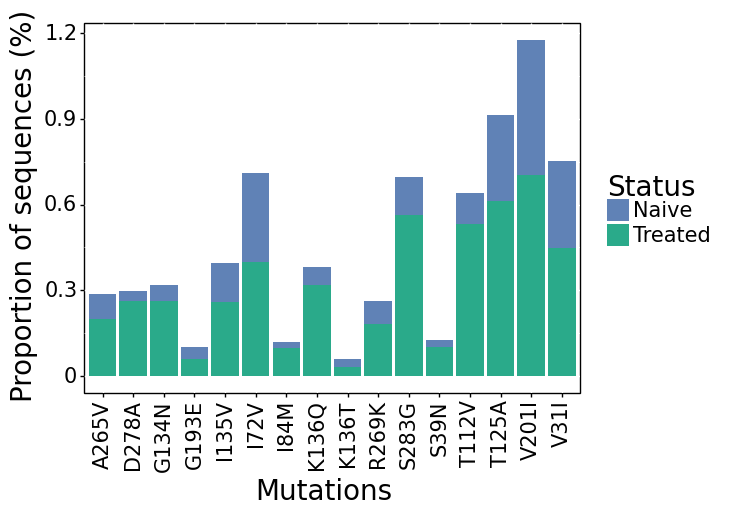

/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 10 x 5 in image.
/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: potential-new-drms-rf.png


In [15]:
# Assume df_results is already computed from the previous code
# Step 1: Subset the DataFrame
subset_results = df_results[df_results['Treated'] > df_results['Naive']]
print(subset_results.shape)
subset_results = subset_results[subset_results['Overall count'] > 1000]
print(subset_results.shape)

# Step 2: Create a bar graph using Plotnine
# Melt the DataFrame to long format for plotting
subset_long = pd.melt(subset_results, id_vars=['Column'], 
                      value_vars=['Naive', 'Treated'], 
                      var_name='Status', value_name='Proportion')

# Create the bar plot
plot = (ggplot(subset_long, aes(x='Column', y='Proportion', fill='Status')) 
        + geom_bar(stat="identity")#, position='dodge')
    + theme(panel_background=element_rect(fill='white'),
            panel_border=element_rect(color='black',size=1),
            axis_text_x=element_text(color='black', size=15, angle=90),
            axis_text_y=element_text(color='black', size=15),
            axis_title=element_text(color='black', size=20),
            legend_text=element_text(color='black', size=15),
            legend_title=element_text(color='black', size=20),
            strip_text=element_text(color='black',size=20),
            strip_background=element_rect(color='black', fill="white"))
        +scale_fill_manual(values = algor_colors)
  #  +coord_flip()
    +theme(legend_position="right")
    + ylab('Proportion of sequences (%)')
    + xlab('Mutations'))

# Display the plot
print(plot)
plot.save("potential-new-drms-rf.png", width=10, height=5, dpi=300)

In [16]:
stanford_muts_instis = stanford_muts[stanford_muts.Drugclass == 'INSTI'].copy()
stanford_muts_major = stanford_muts_instis[stanford_muts_instis['Comment/ Mutation Type'] == 'Major'].copy()
major_drms = stanford_muts_major['Mutation']

identified_muts = variants_data.columns.intersection(major_drms)
identified_muts
major_drms_df = variants_data_full[identified_muts]
major_drms_df.shape

(41247, 33)

In [17]:
subset_results.shape

(16, 10)

In [18]:
new_muts_df = variants_data_full[subset_results['Column'].values]
new_muts_df.shape

(41247, 16)

In [19]:
# Function to calculate Relative Risk
def calculate_relative_risk(major_drms_df, new_muts_df):
    results = []

    # Iterate through each major DRM mutation
    for major_col in major_drms_df.columns:
        # Iterate through each new mutation
        for new_col in new_muts_df.columns:
            # Create a contingency table
            contingency_table = pd.DataFrame({
                'Major_DRM': major_drms_df[major_col],
                'New_Mut': new_muts_df[new_col]
            })

            # Calculate the counts
            counts = contingency_table.value_counts().unstack(fill_value=0)
            
            # Ensure the contingency table has the correct shape
            if counts.shape == (2, 2):
                # Calculate Relative Risk
                a = counts.loc[1, 1]  # Major DRM present, New Mutation present
                b = counts.loc[1, 0]  # Major DRM present, New Mutation absent
                c = counts.loc[0, 1]  # Major DRM absent, New Mutation present
                d = counts.loc[0, 0]  # Major DRM absent, New Mutation absent
                
                # Calculate the risks
                risk_major_drm = a / (a + b) if (a + b) > 0 else 0
                risk_new_mut = c / (c + d) if (c + d) > 0 else 0
                
                # Calculate Relative Risk (RR)
                rr = risk_major_drm / risk_new_mut if risk_new_mut > 0 else None
                
                # Store results
                results.append({
                    'Major_DRM': major_col,
                    'New_Mutation': new_col,
                    'RR': rr
                })

    return pd.DataFrame(results)

# Calculate Relative Risk
rr_results = calculate_relative_risk(major_drms_df, new_muts_df)

# Display results
print(rr_results)

    Major_DRM New_Mutation        RR
0       E138A        A265V  0.159114
1       E138A        D278A  0.228057
2       E138A        G134N  0.000000
3       E138A        G193E  0.000000
4       E138A        I135V  0.057804
..        ...          ...       ...
523     Y143S         S39N  0.194920
524     Y143S        T112V  0.075814
525     Y143S        T125A  0.188622
526     Y143S        V201I  0.168248
527     Y143S         V31I  0.526735

[528 rows x 3 columns]


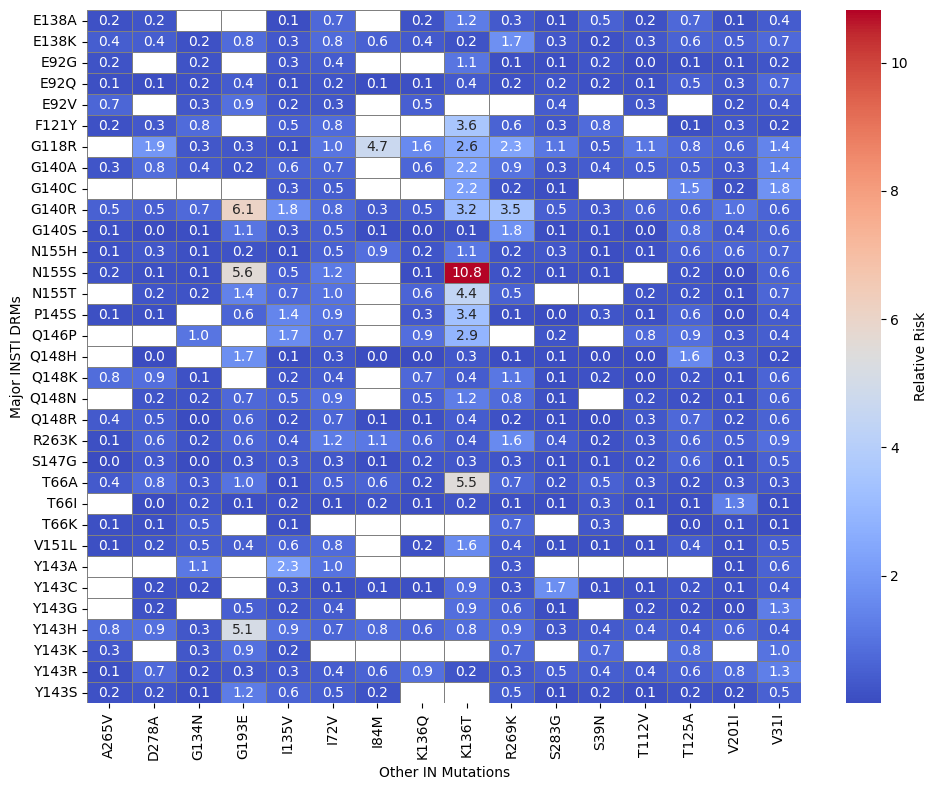

In [92]:
heatmap_data = rr_results.pivot(index='Major_DRM',
                                columns='New_Mutation',
                                values='RR')

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",                     # 👈 THIS controls decimal places
    cmap='coolwarm',
    cbar_kws={'label': 'Relative Risk'},
    linewidths=0.5,
    linecolor='grey'
)

plt.ylabel('Major INSTI DRMs')
plt.xlabel('Other IN Mutations')

plt.tight_layout()
plt.savefig("Relative-risk-potential-major-rf.png", dpi=400, bbox_inches='tight')
plt.show()

In [21]:
subset_results.shape

(16, 10)

In [38]:
selected_muts = list(subset_results['Column'].values)

selected_muts.append('Status')
selected_muts.append('Georegion')
selected_muts.append('subtype2')

variants_data_full['subtype2'] = np.where(variants_data_full['Subtype'] == 'B', 'B', 'non-B')

new_muts_df2 = variants_data_full[selected_muts]
new_muts_df2.shape

(41247, 19)

In [42]:
print(new_muts_df2)

       A265V  D278A  G134N  G193E  I135V  I72V  I84M  K136Q  K136T  R269K  \
0          0      0      0      0      0     0     0      0      0      0   
1          0      0      0      0      0     0     0      0      0      0   
2          0      0      0      0      1     0     0      0      0      0   
3          0      0      0      0      1     0     0      0      0      0   
4          0      0      0      0      1     0     0      0      0      0   
...      ...    ...    ...    ...    ...   ...   ...    ...    ...    ...   
41242      0      0      0      0      1     1     0      0      0      0   
41243      0      0      1      0      1     0     0      0      0      0   
41244      0      0      0      0      0     0     0      0      0      0   
41245      0      0      0      0      0     0     0      0      0      0   
41246      1      1      0      0      0     0     0      1      0      1   

       S283G  S39N  T112V  T125A  V201I  V31I Status      Georegion subtype

In [55]:
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ============================================================
# SETUP
# ============================================================

df = new_muts_df2

georegion_map = {'AFR SSA': 'Africa', 'Africa': 'Africa', 'Asia': 'Asia', 'Europe': 'Europe',
                  'North America': 'North America', 'South America': 'South America'}

# Map levels to values and use 'Others' as the default value
df['Georegion'] = df['Georegion'].map(georegion_map).fillna('Others')

group_cols = ["Status", "Georegion", "subtype2"]
mutation_cols = [c for c in df.columns if c not in group_cols]
print(f"{len(mutation_cols)} mutation columns detected.")

# ============================================================
# 1. PREVALENCE TABLES
# ============================================================

# Overall prevalence (%)
overall_prev = (df[mutation_cols].mean() * 100).round(2).sort_values(ascending=False)

# Prevalence (%) by subtype2 (B vs non-B)
prev_by_subtype = (df.groupby("subtype2")[mutation_cols].mean() * 100).T.round(2)

# Prevalence (%) by Status
prev_by_status = (df.groupby("Status")[mutation_cols].mean() * 100).T.round(2)

# Prevalence (%) by Georegion
prev_by_georegion = (df.groupby("Georegion")[mutation_cols].mean() * 100).T.round(2)

print("\n=== Overall prevalence (%) ===")
print(overall_prev)
print("\n=== Prevalence (%) by subtype2 ===")
print(prev_by_subtype)
print("\n=== Prevalence (%) by Status ===")
print(prev_by_status)
print("\n=== Prevalence (%) by Georegion ===")
print(prev_by_georegion)

# ============================================================
# 2. STATISTICAL TESTS
# ============================================================

# ---- 2a. Prevalence difference: B vs non-B ----
subtype_results = []
for mut in mutation_cols:
    table = pd.crosstab(df[mut], df["subtype2"]).reindex(
        index=[0, 1], fill_value=0
    )
    expected = stats.contingency.expected_freq(table.values)

    if (expected < 5).any():
        _, p_value = stats.fisher_exact(table.values)
        test_used = "Fisher's exact"
    else:
        _, p_value, _, _ = stats.chi2_contingency(table.values)
        test_used = "Chi-square"

    prev_B = df.loc[df["subtype2"] == "B", mut].mean() * 100
    prev_nonB = df.loc[df["subtype2"] == "non-B", mut].mean() * 100

    subtype_results.append({
        "Mutation": mut,
        "Prevalence_B_%": round(prev_B, 2),
        "Prevalence_nonB_%": round(prev_nonB, 2),
        "Test": test_used,
        "p_value": p_value
    })

subtype_results_df = pd.DataFrame(subtype_results)
subtype_results_df["p_adj_BH"] = multipletests(
    subtype_results_df["p_value"], method="fdr_bh"
)[1]
subtype_results_df["Significant_BH_0.05"] = subtype_results_df["p_adj_BH"] < 0.05
subtype_results_df = subtype_results_df.sort_values("p_adj_BH")

print("\n=== Prevalence test: B vs non-B (BH-corrected) ===")
print(subtype_results_df)

# ---- 2b. Prevalence difference: Status (yes vs no) ----
status_results = []
for mut in mutation_cols:
    table = pd.crosstab(df[mut], df["Status"]).reindex(
        index=[0, 1], fill_value=0
    )
    expected = stats.contingency.expected_freq(table.values)

    if (expected < 5).any():
        _, p_value = stats.fisher_exact(table.values)
        test_used = "Fisher's exact"
    else:
        _, p_value, _, _ = stats.chi2_contingency(table.values)
        test_used = "Chi-square"

    prev_yes = df.loc[df["Status"] == "yes", mut].mean() * 100
    prev_no = df.loc[df["Status"] == "no", mut].mean() * 100

    status_results.append({
        "Mutation": mut,
        "Prevalence_yes_%": round(prev_yes, 2),
        "Prevalence_no_%": round(prev_no, 2),
        "Test": test_used,
        "p_value": p_value
    })

status_results_df = pd.DataFrame(status_results)
status_results_df["p_adj_BH"] = multipletests(
    status_results_df["p_value"], method="fdr_bh"
)[1]
status_results_df["Significant_BH_0.05"] = status_results_df["p_adj_BH"] < 0.05
status_results_df = status_results_df.sort_values("p_adj_BH")

print("\n=== Prevalence test: Status yes vs no (BH-corrected) ===")
print(status_results_df)

# ---- 2c. Prevalence difference: across Georegion (overall test) ----
georegion_results = []
for mut in mutation_cols:
    table = pd.crosstab(df[mut], df["Georegion"])
    expected = stats.contingency.expected_freq(table.values)
    sparse_flag = (expected < 5).any()

    _, p_value, _, _ = stats.chi2_contingency(table.values)
    test_used = "Chi-square (sparse cells present)" if sparse_flag else "Chi-square"

    georegion_results.append({
        "Mutation": mut,
        "Test": test_used,
        "p_value": p_value
    })

georegion_results_df = pd.DataFrame(georegion_results)
georegion_results_df["p_adj_BH"] = multipletests(
    georegion_results_df["p_value"], method="fdr_bh"
)[1]
georegion_results_df["Significant_BH_0.05"] = georegion_results_df["p_adj_BH"] < 0.05
georegion_results_df = georegion_results_df.sort_values("p_adj_BH")

print("\n=== Prevalence test: across Georegion (BH-corrected) ===")
print(georegion_results_df)

# ============================================================
# 3. SUMMARY TABLES — n (%) format, merged with test results
# ============================================================

# ---- Subtype summary table ----
subtype_counts = df.groupby("subtype2")[mutation_cols].sum().T
subtype_pct = (df.groupby("subtype2")[mutation_cols].mean() * 100).T.round(2)

subtype_table = pd.DataFrame(index=mutation_cols)
for cat in subtype_counts.columns:
    subtype_table[cat] = [
        f"{int(n)} ({pct}%)"
        for n, pct in zip(subtype_counts[cat], subtype_pct[cat])
    ]
subtype_table = subtype_table.reset_index().rename(columns={"index": "Mutation"})
subtype_table = subtype_table.merge(
    subtype_results_df[["Mutation", "Test", "p_value", "p_adj_BH", "Significant_BH_0.05"]],
    on="Mutation", how="left"
).sort_values("p_adj_BH")

print("\n=== Subtype summary table — n (%) ===")
print(subtype_table)

# ---- Status summary table ----
status_counts = df.groupby("Status")[mutation_cols].sum().T
status_pct = (df.groupby("Status")[mutation_cols].mean() * 100).T.round(2)

status_table = pd.DataFrame(index=mutation_cols)
for cat in status_counts.columns:
    status_table[cat] = [
        f"{int(n)} ({pct}%)"
        for n, pct in zip(status_counts[cat], status_pct[cat])
    ]
status_table = status_table.reset_index().rename(columns={"index": "Mutation"})
status_table = status_table.merge(
    status_results_df[["Mutation", "Test", "p_value", "p_adj_BH", "Significant_BH_0.05"]],
    on="Mutation", how="left"
).sort_values("p_adj_BH")

print("\n=== Status summary table — n (%) ===")
print(status_table)

# ---- Georegion summary table ----
georegion_counts = df.groupby("Georegion")[mutation_cols].sum().T
georegion_pct = (df.groupby("Georegion")[mutation_cols].mean() * 100).T.round(2)

georegion_table = pd.DataFrame(index=mutation_cols)
for cat in georegion_counts.columns:
    georegion_table[cat] = [
        f"{int(n)} ({pct}%)"
        for n, pct in zip(georegion_counts[cat], georegion_pct[cat])
    ]
georegion_table = georegion_table.reset_index().rename(columns={"index": "Mutation"})
georegion_table = georegion_table.merge(
    georegion_results_df[["Mutation", "Test", "p_value", "p_adj_BH", "Significant_BH_0.05"]],
    on="Mutation", how="left"
).sort_values("p_adj_BH")

print("\n=== Georegion summary table — n (%) ===")
print(georegion_table)

# ============================================================
# 4. OPTIONAL EXPORTS
# ============================================================
# subtype_table.to_csv("subtype_summary_table.csv", index=False)
# status_table.to_csv("status_summary_table.csv", index=False)
# georegion_table.to_csv("georegion_summary_table.csv", index=False)

/Users/alfred/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


16 mutation columns detected.

=== Overall prevalence (%) ===
V201I    59.34
T125A    46.32
V31I     37.93
S283G    35.81
I72V     35.75
T112V    32.92
I135V    20.08
K136Q    19.53
G134N    16.29
D278A    15.27
A265V    14.59
R269K    13.37
S39N      6.40
I84M      6.01
G193E     5.16
K136T     2.87
dtype: float64

=== Prevalence (%) by subtype2 ===
subtype2      B  non-B
A265V      8.77  22.84
D278A      0.39  36.37
G134N      0.19  39.10
G193E      5.85   4.19
I135V     11.15  32.73
I72V      27.96  46.78
I84M       1.31  12.68
K136Q      0.48  46.54
K136T      0.42   6.35
R269K      4.83  25.47
S283G      7.54  75.87
S39N       1.74  13.01
T112V      2.69  75.76
T125A     23.13  79.18
V201I     41.84  84.14
V31I      27.14  53.24

=== Prevalence (%) by Status ===
Status     no    yes
A265V    8.90  19.83
D278A    3.28  26.30
G134N    5.32  26.38
G193E    4.49   5.78
I135V   13.89  25.77
I72V    31.30  39.83
I84M     2.01   9.70
K136Q    6.26  31.74
K136T    2.67   3.06
R269K    8.1

In [45]:
from itertools import combinations

# ============================================================
# 2c. Post-hoc pairwise Georegion comparisons
# (only for mutations flagged significant in the omnibus test)
# ============================================================

sig_mutations = georegion_results_df.loc[
    georegion_results_df["Significant_BH_0.05"], "Mutation"
].tolist()

print(f"\n{len(sig_mutations)} mutation(s) significant in omnibus Georegion test: {sig_mutations}")

posthoc_results = []

for mut in sig_mutations:
    regions = df["Georegion"].dropna().unique()
    pairs = list(combinations(sorted(regions), 2))

    for region_a, region_b in pairs:
        subset = df[df["Georegion"].isin([region_a, region_b])]
        table = pd.crosstab(subset[mut], subset["Georegion"]).reindex(
            index=[0, 1], fill_value=0
        )
        # Ensure both regions present as columns
        table = table.reindex(columns=[region_a, region_b], fill_value=0)

        _, p_value = stats.fisher_exact(table.values)

        prev_a = df.loc[df["Georegion"] == region_a, mut].mean() * 100
        prev_b = df.loc[df["Georegion"] == region_b, mut].mean() * 100

        posthoc_results.append({
            "Mutation": mut,
            "Region_A": region_a,
            "Region_B": region_b,
            "Prevalence_A_%": round(prev_a, 2),
            "Prevalence_B_%": round(prev_b, 2),
            "p_value": p_value
        })

posthoc_df = pd.DataFrame(posthoc_results)

# BH correction applied within each mutation, across its own pairwise comparisons
if not posthoc_df.empty:
    posthoc_df["p_adj_BH"] = (
        posthoc_df.groupby("Mutation")["p_value"]
        .transform(lambda p: multipletests(p, method="fdr_bh")[1])
    )
    posthoc_df["Significant_BH_0.05"] = posthoc_df["p_adj_BH"] < 0.05
    posthoc_df = posthoc_df.sort_values(["Mutation", "p_adj_BH"])

print("\n=== Post-hoc pairwise Georegion comparisons (BH-corrected within mutation) ===")
print(posthoc_df)

# posthoc_df.to_csv("georegion_posthoc_pairwise.csv", index=False)


16 mutation(s) significant in omnibus Georegion test: ['A265V', 'D278A', 'G134N', 'I135V', 'I72V', 'I84M', 'K136Q', 'K136T', 'R269K', 'S283G', 'S39N', 'T112V', 'T125A', 'V201I', 'V31I', 'G193E']

=== Post-hoc pairwise Georegion comparisons (BH-corrected within mutation) ===
    Mutation   Region_A         Region_B  Prevalence_A_%  Prevalence_B_%  \
1      A265V    AFR SSA             Asia           49.65            2.01   
4      A265V    AFR SSA           Europe           49.65            5.20   
7      A265V    AFR SSA    North America           49.65            9.83   
5      A265V    AFR SSA      Former USSR           49.65            0.82   
8      A265V    AFR SSA          Oceania           49.65            2.42   
..       ...        ...              ...             ...             ...   
789     V31I       Asia        Caribbean           54.60           48.28   
802     V31I  Caribbean          Oceania           48.28           42.97   
814     V31I     Europe    South America

In [53]:
# ============================================================
# Subtype and Georegion summary tables — n (%) format
# ============================================================

# ---- Subtype table ----
subtype_counts = df.groupby("subtype2")[mutation_cols].sum().T      # counts
subtype_n = df.groupby("subtype2").size()                            # group totals
subtype_pct = (df.groupby("subtype2")[mutation_cols].mean() * 100).T.round(2)  # %

subtype_table = pd.DataFrame(index=mutation_cols)
for cat in subtype_counts.columns:
    subtype_table[cat] = [
        f"{int(n)} ({pct}%)"
        for n, pct in zip(subtype_counts[cat], subtype_pct[cat])
    ]
subtype_table = subtype_table.reset_index().rename(columns={"index": "Mutation"})

subtype_table = subtype_table.merge(
    subtype_results_df[["Mutation", "Test", "p_value", "p_adj_BH", "Significant_BH_0.05"]],
    on="Mutation",
    how="left"
)
subtype_table = subtype_table.sort_values("p_adj_BH")

print("=== Subtype summary table — n (%) ===")
print(subtype_table)

# ---- Georegion table ----
georegion_counts = df.groupby("Georegion")[mutation_cols].sum().T
georegion_pct = (df.groupby("Georegion")[mutation_cols].mean() * 100).T.round(2)

georegion_table = pd.DataFrame(index=mutation_cols)
for cat in georegion_counts.columns:
    georegion_table[cat] = [
        f"{int(n)} ({pct}%)"
        for n, pct in zip(georegion_counts[cat], georegion_pct[cat])
    ]
georegion_table = georegion_table.reset_index().rename(columns={"index": "Mutation"})

georegion_table = georegion_table.merge(
    georegion_results_df[["Mutation", "Test", "p_value", "p_adj_BH", "Significant_BH_0.05"]],
    on="Mutation",
    how="left"
)
georegion_table = georegion_table.sort_values("p_adj_BH")

print("\n=== Georegion summary table — n (%) ===")
print(georegion_table)

# subtype_table.to_csv("subtype_summary_table.csv", index=False)
# georegion_table.to_csv("georegion_summary_table.csv", index=False)

=== Subtype summary table — n (%) ===
   Mutation               B           non-B        Test        p_value  \
0     A265V    2121 (8.77%)   3897 (22.84%)  Chi-square   0.000000e+00   
1     D278A      94 (0.39%)   6205 (36.37%)  Chi-square   0.000000e+00   
2     G134N      46 (0.19%)    6672 (39.1%)  Chi-square   0.000000e+00   
4     I135V   2697 (11.15%)   5584 (32.73%)  Chi-square   0.000000e+00   
5      I72V   6763 (27.96%)   7981 (46.78%)  Chi-square   0.000000e+00   
6      I84M     317 (1.31%)   2164 (12.68%)  Chi-square   0.000000e+00   
7     K136Q     116 (0.48%)   7941 (46.54%)  Chi-square   0.000000e+00   
9     R269K    1168 (4.83%)   4346 (25.47%)  Chi-square   0.000000e+00   
10    S283G    1824 (7.54%)  12945 (75.87%)  Chi-square   0.000000e+00   
11     S39N     422 (1.74%)   2219 (13.01%)  Chi-square   0.000000e+00   
12    T112V     651 (2.69%)  12926 (75.76%)  Chi-square   0.000000e+00   
13    T125A   5595 (23.13%)  13509 (79.18%)  Chi-square   0.000000e+00   


In [51]:
# ============================================================
# Proportion of Status by Georegion — combined "n (%)" format
# ============================================================

status_by_region_counts = pd.crosstab(df["Georegion"], df["Status"])
status_by_region_prop = pd.crosstab(
    df["Georegion"], df["Status"], normalize="index"
) * 100

status_by_region_table = pd.DataFrame(index=status_by_region_counts.index)

for status_cat in status_by_region_counts.columns:
    n = status_by_region_counts[status_cat]
    pct = status_by_region_prop[status_cat].round(2)
    status_by_region_table[status_cat] = [
        f"{n_val} ({pct_val}%)" for n_val, pct_val in zip(n, pct)
    ]

status_by_region_table["N_total"] = status_by_region_counts.sum(axis=1)
status_by_region_table = status_by_region_table.reset_index()

print("=== Status by Georegion — n (%) ===")
print(status_by_region_table)

# Chi-square test: Status distribution across Georegion
table = pd.crosstab(df["Status"], df["Georegion"])
chi2, p_value, dof, expected = stats.chi2_contingency(table.values)
print(f"\nChi-square test (Status x Georegion): p = {p_value:.4g}")

# status_by_region_table.to_csv("status_by_georegion.csv", index=False)

# Optional exports
# subtype_table.to_csv("subtype_summary_table.csv", index=False)
# georegion_table.to_csv("georegion_summary_table.csv", index=False)

=== Status by Georegion — n (%) ===
       Georegion              no            yes  N_total
0         Africa    839 (10.95%)  6826 (89.05%)     7665
1           Asia   1031 (12.14%)  7464 (87.86%)     8495
2         Europe   2433 (57.49%)  1799 (42.51%)     4232
3  North America  14767 (83.13%)  2997 (16.87%)    17764
4         Others    516 (19.47%)  2134 (80.53%)     2650
5  South America    176 (39.91%)   265 (60.09%)      441

Chi-square test (Status x Georegion): p = 0


In [56]:
# ============================================================
# Denominators (group sizes) for Status, Georegion, subtype2
# ============================================================

print("=== N by Status ===")
print(df["Status"].value_counts())

print("\n=== N by Georegion ===")
print(df["Georegion"].value_counts())

print("\n=== N by subtype2 ===")
print(df["subtype2"].value_counts())

print(f"\nTotal N: {len(df)}")

=== N by Status ===
yes    21485
no     19762
Name: Status, dtype: int64

=== N by Georegion ===
North America    17764
Asia              8495
Africa            7665
Europe            4232
Others            2650
South America      441
Name: Georegion, dtype: int64

=== N by subtype2 ===
B        24185
non-B    17062
Name: subtype2, dtype: int64

Total N: 41247


In [60]:
import pandas as pd
import numpy as np
from scipy import stats

def calculate_relative_risk(major_drms_df, new_muts_df):
    results = []
    
    for major_col in major_drms_df.columns:
        for new_col in new_muts_df.columns:
            
            contingency_table = pd.DataFrame({
                'Major_DRM': major_drms_df[major_col],
                'New_Mut': new_muts_df[new_col]
            })
            
            counts = contingency_table.value_counts().unstack(fill_value=0)
            
            if counts.shape == (2, 2):
                a = counts.loc[1, 1]  # DRM+, RAM+
                b = counts.loc[1, 0]  # DRM+, RAM-
                c = counts.loc[0, 1]  # DRM-, RAM+
                d = counts.loc[0, 0]  # DRM-, RAM-
                
                risk_major_drm = a / (a + b) if (a + b) > 0 else 0
                risk_new_mut = c / (c + d) if (c + d) > 0 else 0
                
                # Relative Risk
                rr = risk_major_drm / risk_new_mut if risk_new_mut > 0 else None
                
                # --- 95% CI for RR (Wald log method) ---
                if rr and rr > 0 and a > 0 and b > 0 and c > 0 and d > 0:
                    log_rr = np.log(rr)
                    se_log_rr = np.sqrt((1/a) - (1/(a+b)) + (1/c) - (1/(c+d)))
                    ci_lower = np.exp(log_rr - 1.96 * se_log_rr)
                    ci_upper = np.exp(log_rr + 1.96 * se_log_rr)
                else:
                    ci_lower, ci_upper = None, None
                
                # --- p-value (Fisher's Exact Test) ---
                contingency_matrix = np.array([[a, b], [c, d]])
                _, p_value = stats.fisher_exact(contingency_matrix)
                
                results.append({
                    'Major_DRM': major_col,
                    'New_Mutation': new_col,
                    'a (DRM+/RAM+)': a,
                    'b (DRM+/RAM-)': b,
                    'c (DRM-/RAM+)': c,
                    'd (DRM-/RAM-)': d,
                    'RR': round(rr, 3) if rr else None,
                    'CI_lower': round(ci_lower, 3) if ci_lower else None,
                    'CI_upper': round(ci_upper, 3) if ci_upper else None,
                    'p_value': round(p_value, 4)
                })
    
    df = pd.DataFrame(results)
    
    # --- FDR correction (Benjamini-Hochberg) ---
    from statsmodels.stats.multitest import multipletests
    valid = df['p_value'].notna()
    df.loc[valid, 'p_adjusted'] = multipletests(
        df.loc[valid, 'p_value'], method='fdr_bh'
    )[1].round(4)
    
    return df

# Run
rr_results = calculate_relative_risk(major_drms_df, new_muts_df)

# Filter RR >= 1.5 AND statistically significant
filtered = rr_results[
    (rr_results['RR'] >= 1.5) & 
    (rr_results['p_adjusted'] < 0.05) &
    (rr_results['CI_lower'] > 1.0)  # CI does not cross 1
]

print(filtered)
#filtered.to_csv('filtered_relative_risk.csv')

    Major_DRM New_Mutation  a (DRM+/RAM+)  b (DRM+/RAM-)  c (DRM-/RAM+)  \
25      E138K        R269K            118            393           5396   
88      F121Y        K136T              4             35           1180   
97      G118R        D278A             20             48           6279   
102     G118R         I84M             19             49           2462   
103     G118R        K136Q             21             47           8036   
105     G118R        R269K             21             47           5493   
143     G140C         V31I             21             10          15626   
147     G140R        G193E             44             99           2085   
148     G140R        I135V             51             92           8230   
152     G140R        K136T             13            130           1171   
153     G140R        R269K             66             77           5448   
169     G140S        R269K            194            627           5320   
195     N155S        G193

In [61]:
filtered.shape

(23, 11)

/Users/alfred/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "width" which is no longer supported as of 3.3 and will become an error in 3.6
/Users/alfred/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:67: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "height" which is no longer supported as of 3.3 and will become an error in 3.6


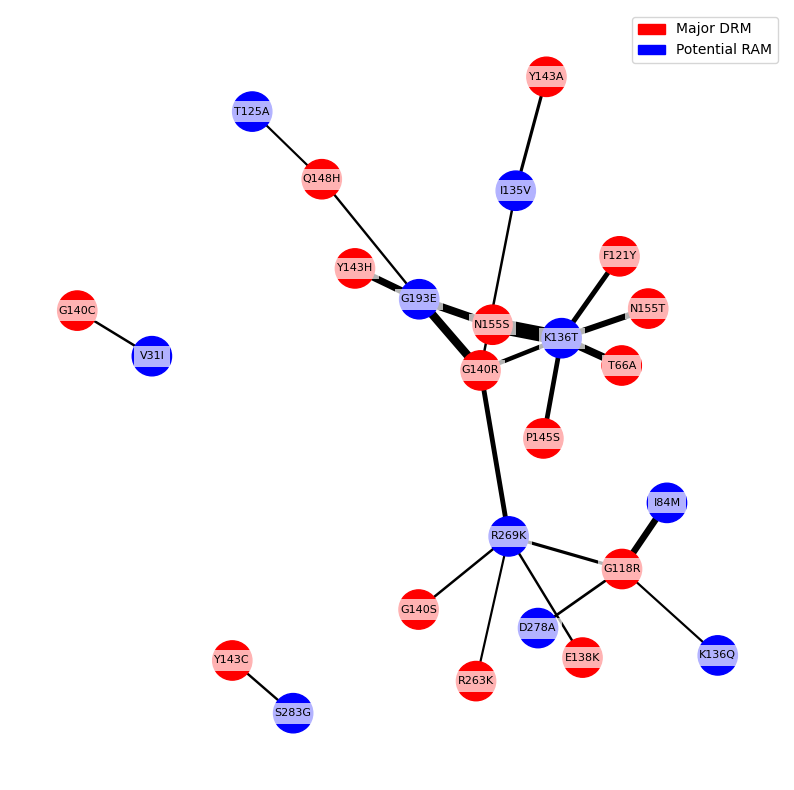

In [91]:
import pandas as pd

rr_filtered = filtered

import networkx as nx

G = nx.Graph()

# Add major DRM nodes
for drm in rr_filtered["Major_DRM"].unique():
    G.add_node(drm, type="major")

# Add new mutation nodes
for mut in rr_filtered["New_Mutation"].unique():
    G.add_node(mut, type="putative")

# Add weighted edges
for _, row in rr_filtered.iterrows():
    G.add_edge(
        row["Major_DRM"],
        row["New_Mutation"],
        weight=row["RR"]
    )
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
sorted(weighted_degree.items(), key=lambda x: x[1], reverse=True)[:10]


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

pos = nx.spring_layout(G, k=0.6, seed=32)

node_colors = [
    "red" if G.nodes[n]["type"] == "major" else "blue"
    for n in G.nodes()
]

edge_widths = [G[u][v]["weight"] for u, v in G.edges()]

plt.figure(figsize=(10,10))

# Draw nodes and edges (no labels yet)
nx.draw_networkx_nodes(G, pos,
                       node_color=node_colors,
                       node_size=800)

nx.draw_networkx_edges(G, pos,
                       width=edge_widths)

# Draw readable labels with white background
nx.draw_networkx_labels(
    G, pos,
    font_size=8,
    font_color='black',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
)

# Legend
major_patch = mpatches.Patch(color='red', label='Major DRM')
putative_patch = mpatches.Patch(color='blue', label='Potential RAM')
plt.legend(handles=[major_patch, putative_patch], loc='best')

# plt.title("Bipartite Network of Major and Putative RAMs")
plt.axis("off")
plt.savefig("Bipartite-network-filtered-on-CI.png", width=22, height=7, dpi=400, bbox_inches='tight')
plt.show()